In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
playstore_df=pd.read_csv("googleplaystore.csv")
playstore_review_df=pd.read_csv("googleplaystore_user_reviews.csv")
playstore_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
playstore_review_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [4]:
playstore_review_df.shape

(64295, 5)

In [5]:
playstore_df.shape

(10841, 13)

In [6]:
playstore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
playstore_df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [9]:
## How are apps distributed across different categories?
playstore_df['Category'].value_counts().sort_values(ascending=True)

Category
1.9                       1
BEAUTY                   53
PARENTING                60
COMICS                   60
EVENTS                   64
ART_AND_DESIGN           65
WEATHER                  82
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
HOUSE_AND_HOME           88
FOOD_AND_DRINK          127
MAPS_AND_NAVIGATION     137
ENTERTAINMENT           149
EDUCATION               156
VIDEO_PLAYERS           175
BOOKS_AND_REFERENCE     231
DATING                  234
TRAVEL_AND_LOCAL        258
SHOPPING                260
NEWS_AND_MAGAZINES      283
SOCIAL                  295
PHOTOGRAPHY             335
HEALTH_AND_FITNESS      341
FINANCE                 366
LIFESTYLE               382
SPORTS                  384
COMMUNICATION           387
PERSONALIZATION         392
PRODUCTIVITY            424
BUSINESS                460
MEDICAL                 463
TOOLS                   843
GAME                   1144
FAMILY                 1972
Name: count, dtype: int64

In [10]:
playstore_df.groupby("Category")["App"].count().sort_values(ascending=True)

Category
1.9                       1
BEAUTY                   53
COMICS                   60
PARENTING                60
EVENTS                   64
ART_AND_DESIGN           65
WEATHER                  82
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
HOUSE_AND_HOME           88
FOOD_AND_DRINK          127
MAPS_AND_NAVIGATION     137
ENTERTAINMENT           149
EDUCATION               156
VIDEO_PLAYERS           175
BOOKS_AND_REFERENCE     231
DATING                  234
TRAVEL_AND_LOCAL        258
SHOPPING                260
NEWS_AND_MAGAZINES      283
SOCIAL                  295
PHOTOGRAPHY             335
HEALTH_AND_FITNESS      341
FINANCE                 366
LIFESTYLE               382
SPORTS                  384
COMMUNICATION           387
PERSONALIZATION         392
PRODUCTIVITY            424
BUSINESS                460
MEDICAL                 463
TOOLS                   843
GAME                   1144
FAMILY                 1972
Name: App, dtype: int64

In [11]:
playstore_df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [12]:
len(playstore_df["Category"].unique())

34

In [13]:
## How do app ratings vary across categories?
playstore_df.groupby("Category")["Rating"].agg(["mean","sum","count"])

,mean,sum,count
Category,,,
1.9,19.000000,19.0,1
ART_AND_DESIGN,4.358065,270.2,62
AUTO_AND_VEHICLES,4.190411,305.9,73
BEAUTY,4.278571,179.7,42
BOOKS_AND_REFERENCE,4.346067,773.6,178
BUSINESS,4.121452,1248.8,303
COMICS,4.155172,241.0,58
COMMUNICATION,4.158537,1364.0,328
DATING,3.970769,774.3,195


In [14]:
## What is the distribution of ratings across all apps?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [15]:
playstore_df['Rating'].value_counts()

Rating
4.4     1109
4.3     1076
4.5     1038
4.2      952
4.6      823
4.1      708
4.0      568
4.7      499
3.9      386
3.8      303
5.0      274
3.7      239
4.8      234
3.6      174
3.5      163
3.4      128
3.3      102
4.9       87
3.0       83
3.1       69
3.2       64
2.9       45
2.8       42
2.6       25
2.7       25
2.5       21
2.3       20
2.4       19
1.0       16
2.2       14
1.9       13
2.0       12
1.7        8
1.8        8
2.1        8
1.6        4
1.4        3
1.5        3
1.2        1
19.0       1
Name: count, dtype: int64

In [16]:
playstore_df_clean=playstore_df.dropna(subset=['Rating'])
playstore_df_clean = playstore_df[(playstore_df['Rating'] >= 0) & (playstore_df['Rating'] <= 5)]
fig=px.histogram(
    playstore_df_clean,
    x='Rating',
    nbins=20,
    title="Distibution of Ratings Across all apps")
fig.show()

In [17]:
## How do the number of installs vary across app categories?
## Installs,Categories
playstore_df[["Installs","Category"]].head()

,Installs,Category
0,"10,000+",ART_AND_DESIGN
1,"500,000+",ART_AND_DESIGN
2,"5,000,000+",ART_AND_DESIGN
3,"50,000,000+",ART_AND_DESIGN
4,"100,000+",ART_AND_DESIGN


In [18]:
playstore_df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [19]:
playstore_df.loc[playstore_df["Installs"] == "Free", "Installs"]

10472    Free
Name: Installs, dtype: object

In [20]:
playstore_df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [21]:
(playstore_df['Installs'] == 'Free').sum()

np.int64(1)

In [22]:
playstore_df['Installs']=playstore_df['Installs'].str.replace(',','')
playstore_df['Installs']=playstore_df['Installs'].str.replace('+','')
playstore_df=playstore_df[playstore_df["Installs"]!="Free"]
playstore_df['Installs']=playstore_df['Installs'].astype(int)
install_by_cat=playstore_df.groupby('Category')["Installs"].agg(["sum","mean"])


In [23]:
install_by_cat

,sum,mean
Category,,
ART_AND_DESIGN,124338100,1.912894e+06
AUTO_AND_VEHICLES,53130211,6.250613e+05
BEAUTY,27197050,5.131519e+05
BOOKS_AND_REFERENCE,1921469576,8.318050e+06
BUSINESS,1001914865,2.178076e+06
COMICS,56086150,9.347692e+05
COMMUNICATION,32647276251,8.435989e+07
DATING,264310807,1.129533e+06
EDUCATION,871452000,5.586231e+06


In [24]:
install_sum=(playstore_df
             .groupby("Category")["Installs"]
             .sum()
             .sort_values(ascending=False))
install_sum

Category
GAME                   35086024415
COMMUNICATION          32647276251
PRODUCTIVITY           14176091369
SOCIAL                 14069867902
TOOLS                  11452771915
FAMILY                 10258263505
PHOTOGRAPHY            10088247655
NEWS_AND_MAGAZINES      7496317760
TRAVEL_AND_LOCAL        6868887146
VIDEO_PLAYERS           6222002720
SHOPPING                3247848785
ENTERTAINMENT           2869160000
PERSONALIZATION         2325494782
BOOKS_AND_REFERENCE     1921469576
SPORTS                  1751174498
HEALTH_AND_FITNESS      1583072512
BUSINESS                1001914865
FINANCE                  876648734
EDUCATION                871452000
MAPS_AND_NAVIGATION      724281890
LIFESTYLE                537643539
WEATHER                  426100520
FOOD_AND_DRINK           273898751
DATING                   264310807
HOUSE_AND_HOME           168712461
ART_AND_DESIGN           124338100
LIBRARIES_AND_DEMO        62995910
COMICS                    56086150
MEDICAL    

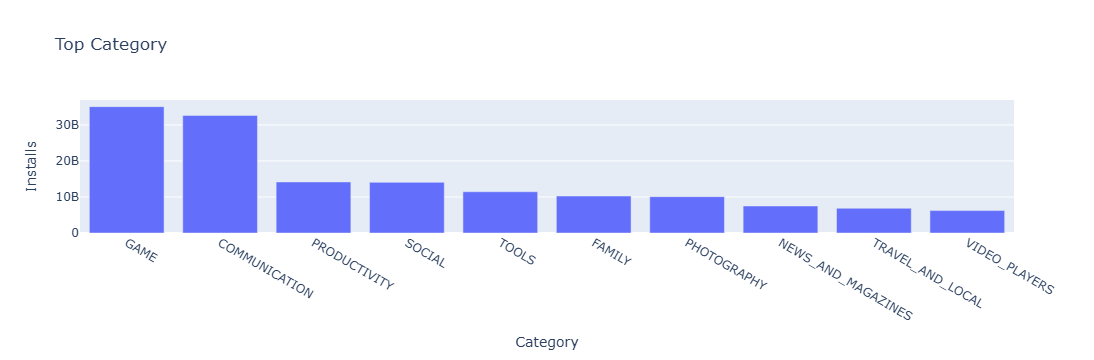

In [76]:
fig=px.bar(
    install_sum.head(10).reset_index(),
    x="Category",
    y="Installs",
    title="Top Category")
fig.show()

In [26]:
## How does the relationship between installs and reviews look across apps?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [27]:
playstore_df[["Installs","Reviews","App"]].head(10)

,Installs,Reviews,App
0,10000,159,Photo Editor & Candy Camera & Grid & ScrapBook
1,500000,967,Coloring book moana
2,5000000,87510,"U Launcher Lite – FREE Live Cool Themes, Hide ..."
3,50000000,215644,Sketch - Draw & Paint
4,100000,967,Pixel Draw - Number Art Coloring Book
5,50000,167,Paper flowers instructions
6,50000,178,Smoke Effect Photo Maker - Smoke Editor
7,1000000,36815,Infinite Painter
8,1000000,13791,Garden Coloring Book
9,10000,121,Kids Paint Free - Drawing Fun


In [28]:
playstore_df[['Installs', 'Reviews']].corr()
## There is a positive relationship between install goes up and reviewss also goes up

,Installs,Reviews
Installs,1.000000,0.643122
Reviews,0.643122,1.000000


In [29]:
playstore_df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs            int64
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [30]:
playstore_df["Reviews"]=pd.to_numeric(playstore_df["Reviews"],errors="coerce")
playstore_df=playstore_df.dropna(subset=["Installs","Reviews"])

In [31]:
fig=px.scatter(playstore_df,
               x="Installs",
               y="Reviews",
               title="Install vs reviews",
               log_x=True,
               log_y=True,
               opacity=0.5)
fig.show()

In [32]:
## How do free and paid apps compare in terms of count?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [33]:
playstore_df["Type"].value_counts()

Type
Free    10039
Paid      800
Name: count, dtype: int64

In [34]:
## How do ratings differ between free and paid apps?
playstore_df.groupby("Type")["Rating"].mean().sort_values(ascending=False)

Type
Paid    4.266615
Free    4.186203
Name: Rating, dtype: float64

In [35]:
fig=px.box(
    playstore_df,
    x="Type",
    y="Rating",
    title="rating Vs Type")
fig.show()

In [36]:
## 8)What is the distribution of app prices for paid apps?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [37]:
playstore_df['Price'] = playstore_df['Price'].astype(str)
playstore_df['Price'] = playstore_df['Price'].str.replace('$', '')
playstore_df['Price'] = pd.to_numeric(playstore_df['Price'], errors='coerce')

In [38]:
paid_apps=playstore_df[playstore_df["Type"]=="Paid"]
paid_apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6.8M,100000,Paid,4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39M,100000,Paid,4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
290,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6.8M,100000,Paid,4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
291,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39M,100000,Paid,4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
427,Puffin Browser Pro,COMMUNICATION,4.0,18247,Varies with device,100000,Paid,3.99,Everyone,Communication,"July 5, 2018",7.5.3.20547,4.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10735,FP VoiceBot,FAMILY,NaN,17,157k,100,Paid,0.99,Mature 17+,Entertainment,"November 25, 2015",1.2,2.1 and up
10760,Fast Tract Diet,HEALTH_AND_FITNESS,4.4,35,2.4M,1000,Paid,7.99,Everyone,Health & Fitness,"August 8, 2018",1.9.3,4.2 and up
10782,Trine 2: Complete Story,GAME,3.8,252,11M,10000,Paid,16.99,Teen,Action,"February 27, 2015",2.22,5.0 and up
10785,"sugar, sugar",FAMILY,4.2,1405,9.5M,10000,Paid,1.20,Everyone,Puzzle,"June 5, 2018",2.7,2.3 and up


In [39]:
fig=px.histogram(
    paid_apps,
    x="Price",
    nbins=20,
    title="Distributions of Apps Prices")
fig.show()

In [40]:
fig = px.box(
    paid_apps,
    y='Price',
    title="Boxplot of App Prices"
)

fig.show()

In [41]:
## Q9. How does app price relate to number of installs?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [42]:
playstore_df[["Price","Installs"]].corr()

,Price,Installs
Price,1.000000,-0.011689
Installs,-0.011689,1.000000


In [43]:
fig=px.scatter(
    playstore_df,
    x="Price",
    y="Installs",
    log_y=True,
    title="Price vs Installs")
fig.show()

In [44]:
paid_apps=playstore_df[playstore_df["Price"]>0]
fig=px.scatter(
    paid_apps,
    x="Price",
    y="Installs",
    log_y=True,
    title="Price vs install(paid)")
fig.show()

In [45]:
## Q10. How do content ratings differ across app categories?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [46]:
playstore_df["Content Rating"].value_counts()

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

In [47]:
pd.crosstab(playstore_df["Category"],playstore_df["Content Rating"]
        )

Content Rating,Adults only 18+,Everyone,Everyone 10+,Mature 17+,Teen,Unrated
Category,,,,,,
ART_AND_DESIGN,0,61,1,0,3,0
AUTO_AND_VEHICLES,0,83,1,0,1,0
BEAUTY,0,45,2,3,3,0
BOOKS_AND_REFERENCE,0,202,5,3,21,0
BUSINESS,0,445,1,1,13,0
COMICS,2,26,3,7,22,0
COMMUNICATION,0,345,0,10,32,0
DATING,0,21,0,201,12,0
EDUCATION,0,144,8,3,1,0


In [48]:
ct=pd.crosstab(
    playstore_df["Category"],
    playstore_df["Content Rating"]).reset_index()
fig=px.bar(
    ct,
    x="Category",
    y=ct.columns[1:],
    title="Content Rating")
fig.show()

In [49]:
## Q11. How does app size vary across different categories?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [50]:
playstore_df["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [51]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024
    else:
        return None
playstore_df['Size_MB']=playstore_df['Size'].apply(convert_size)

In [52]:
playstore_df=playstore_df.dropna(subset=['Size_MB'])

In [53]:
size_by_cat=playstore_df.groupby("Category")['Size_MB'].mean().sort_values(ascending=False)
size_by_cat

Category
GAME                   44.370065
FAMILY                 28.319023
TRAVEL_AND_LOCAL       24.654463
SPORTS                 24.338822
HEALTH_AND_FITNESS     22.768851
PARENTING              22.512963
FOOD_AND_DRINK         22.185000
ENTERTAINMENT          21.853333
EDUCATION              20.790600
AUTO_AND_VEHICLES      20.036807
MEDICAL                19.628456
FINANCE                17.928309
SOCIAL                 17.681671
PHOTOGRAPHY            17.367574
DATING                 16.625555
MAPS_AND_NAVIGATION    16.614368
SHOPPING               16.175059
VIDEO_PLAYERS          16.084441
HOUSE_AND_HOME         15.978539
LIFESTYLE              14.754111
BUSINESS               14.471877
EVENTS                 13.963617
BEAUTY                 13.795745
COMICS                 13.484869
BOOKS_AND_REFERENCE    13.310188
WEATHER                13.124006
NEWS_AND_MAGAZINES     13.023615
PRODUCTIVITY           12.980885
ART_AND_DESIGN         12.370968
COMMUNICATION          11.765673
P

In [54]:
fig=px.bar(
    size_by_cat.reset_index(),
    x='Category',
    y="Size_MB",
    title="Average App Size By Category")
fig.show()
    

In [55]:
## How frequently are apps updated over time?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB'],
      dtype='object')

In [56]:
playstore_df.dtypes

App                object
Category           object
Rating            float64
Reviews             int64
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Size_MB           float64
dtype: object

In [57]:
playstore_df['Last Updated']=pd.to_datetime(playstore_df['Last Updated'],errors='coerce')


In [58]:
playstore_df.dropna(subset=['Last Updated'])

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,FR Forms,BUSINESS,NaN,0,9.6M,10,Free,0.0,Everyone,Business,2016-09-29,1.1.5,4.0 and up,9.6
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,53.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,3.6
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up,9.5


In [59]:
playstore_df["Year"]=playstore_df['Last Updated'].dt.year

In [60]:
updated_year=playstore_df["Year"].value_counts()
updated_year

Year
2018    5868
2017    1738
2016     749
2015     443
2014     201
2013     105
2012      25
2011      15
2010       1
Name: count, dtype: int64

In [61]:
fig=px.bar(
    updated_year.reset_index(),
    x="Year",
    y="count",
    title="Apps Updated Over time")
fig.show()

In [62]:
## How do genres compare in terms of app count and popularity?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB', 'Year'],
      dtype='object')

In [63]:
genre_count=(playstore_df['Genres'].value_counts())
genre_count

Genres
Tools                       739
Entertainment               537
Education                   496
Medical                     434
Business                    400
                           ... 
Role Playing;Education        1
Role Playing;Brain Games      1
Strategy;Education            1
Racing;Pretend Play           1
Strategy;Creativity           1
Name: count, Length: 116, dtype: int64

In [64]:
genre_installs=playstore_df.groupby('Genres')["Installs"].sum().sort_values(ascending=False)

In [65]:
fig = px.bar(
    genre_installs.head(10).reset_index(),
    x='Genres',
    y='Installs',
    title="Top Genres by Total Installs"
)

fig.show()

In [66]:
fig=px.bar(
    genre_count.head(10).reset_index(),
    x="Genres",
    y="count",
    title="Top Genres by App Count")
fig.show()

In [67]:
## Are higher-rated apps concentrated in specific categories?
playstore_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB', 'Year'],
      dtype='object')

In [68]:
playstore_df["Category"].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

In [69]:
high_apps=playstore_df[playstore_df["Rating"]>=4.5]
high_apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Year
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,2018
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,10000,Free,0.0,Everyone,Art & Design;Creativity,2018-07-03,2.8,4.0.3 and up,3.1,2018
13,Mandala Coloring Book,ART_AND_DESIGN,4.6,4326,21M,100000,Free,0.0,Everyone,Art & Design,2018-06-26,1.0.4,4.4 and up,21.0,2018
16,Photo Designer - Write your name with shapes,ART_AND_DESIGN,4.7,3632,5.5M,500000,Free,0.0,Everyone,Art & Design,2018-07-31,3.1,4.1 and up,5.5,2018


In [70]:
high_counts=high_apps["Category"].value_counts()
high_counts

Category
FAMILY                 508
GAME                   331
TOOLS                  140
MEDICAL                133
HEALTH_AND_FITNESS     114
PERSONALIZATION        110
LIFESTYLE               98
FINANCE                 92
SPORTS                  78
BUSINESS                78
PRODUCTIVITY            71
BOOKS_AND_REFERENCE     69
PHOTOGRAPHY             61
NEWS_AND_MAGAZINES      59
SHOPPING                58
SOCIAL                  57
EDUCATION               49
COMMUNICATION           36
DATING                  32
TRAVEL_AND_LOCAL        32
FOOD_AND_DRINK          28
ART_AND_DESIGN          26
VIDEO_PLAYERS           26
PARENTING               22
EVENTS                  21
MAPS_AND_NAVIGATION     20
AUTO_AND_VEHICLES       20
COMICS                  18
BEAUTY                  15
HOUSE_AND_HOME          15
LIBRARIES_AND_DEMO      15
WEATHER                 15
ENTERTAINMENT           13
Name: count, dtype: int64

In [71]:
high_ratio=playstore_df.groupby('Category')["Rating"].apply(lambda x : (x>=4.5).mean()).sort_values(ascending=False)
high_ratio
                                                      

Category
EDUCATION              0.441441
HEALTH_AND_FITNESS     0.431818
ART_AND_DESIGN         0.419355
PARENTING              0.407407
EVENTS                 0.368421
COMICS                 0.352941
BOOKS_AND_REFERENCE    0.350254
GAME                   0.326108
BEAUTY                 0.319149
PERSONALIZATION        0.309859
MEDICAL                0.306452
FINANCE                0.299674
SHOPPING               0.288557
LIFESTYLE              0.284058
FOOD_AND_DRINK         0.280000
FAMILY                 0.277293
NEWS_AND_MAGAZINES     0.273148
SOCIAL                 0.271429
AUTO_AND_VEHICLES      0.266667
WEATHER                0.263158
SPORTS                 0.250804
PHOTOGRAPHY            0.240157
PRODUCTIVITY           0.234323
HOUSE_AND_HOME         0.220588
VIDEO_PLAYERS          0.198473
BUSINESS               0.195000
TOOLS                  0.189445
MAPS_AND_NAVIGATION    0.185185
LIBRARIES_AND_DEMO     0.182927
TRAVEL_AND_LOCAL       0.166667
DATING                 0.150943

In [72]:
fig=px.bar(
    high_ratio.head(10).reset_index(),
    x="Category",
    y="Rating",
    title="Categories with High Proportion")
fig.show()

In [74]:
playstore_df = playstore_df.dropna(subset=['Rating', 'Reviews', 'Installs'])

In [73]:
## Q15. What patterns emerge when considering ratings, reviews, and installs together?
playstore_df[['Installs', 'Reviews', 'Rating']].corr()

,Installs,Reviews,Rating
Installs,1.000000,0.627720,0.052705
Reviews,0.627720,1.000000,0.079823
Rating,0.052705,0.079823,1.000000
